## Load in packages and data

In [1]:
import numpy as np
import pandas as pd
# import geopandas as gpd
import matplotlib.pyplot as plt
import matsim_output_analysis as moa
import operator

In [2]:
# df = pd.read_csv(r"20000_sample.csv") #using look3, ignoring some fields such as carCO2
# df = pd.read_csv(r"BT_plans.csv")
df = pd.read_csv(r"07042026_test1.csv") #this is the output-londinium-edited1 output with mangled plans
# df = pd.read_csv(r"NTI_20000_sample_routes.csv")
# df = pd.read_csv("sampled_plans_2040_dn_250.csv") # this is experienced plans!
# df_spare = df #for resetting if needed

In [3]:
df["negative_utility_somewhere"] = df.apply(lambda row: moa.neg_utility_somewhere(row), axis=1)
x = (sum(df["negative_utility_somewhere"])/len(df))*100
print(str(round(x,2))+" pc of people have a negative utility")


2.0 pc of people have a negative utility


In [4]:
#turn plan summaries into lists instead of long strings
df['selected plan activity_type_or_mode'] = df['selected plan activity_type_or_mode'].str.split('; ')
df['selected plan distance_travelled'] = df['selected plan distance_travelled'].str.split('; ')
df['selected plan duration'] = df['selected plan duration'].str.split('; ')
df['selected plan location'] = df['selected plan location'].str.split('; ')
df['selected plan routes'] = df['selected plan routes'].str.split('; ')
df['selected plan boardingTime'] = df['selected plan boardingTime'].str.split('; ')

## Remove "pt interaction" terms and all corresponding columns

In [5]:
#extract the indices of where pt interaction happens
df['selected plan ptinteraction_indices'] = df['selected plan activity_type_or_mode'].apply(moa.get_ptinteraction_index)

In [6]:
#remove the pt interaction activities
df['selected plan activity_type_or_mode'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan activity_type_or_mode']), axis=1)

In [7]:
#remove the correspinding pt interaction durations
df['selected plan duration'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan duration']), axis=1)

In [8]:
#remove the correspinding pt interaction locations
df['selected plan location'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan location']), axis=1)

In [9]:
#remove the correspinding pt interaction distance travelled
df['selected plan distance_travelled'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan distance_travelled']), axis=1)

In [10]:
#remove the correspinding pt interaction distance travelled
df['selected plan boardingTime'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan boardingTime']), axis=1)

In [11]:
#clean  up table and remove indices
df = df.drop(["selected plan ptinteraction_indices","unselected plan (1) activity_type_or_mode", "unselected plan (1) distance_travelled", "unselected plan (1) duration", "unselected plan (1) location", "unselected plan (1) routes", "unselected plan (1) number", "unselected plan (1) utility",
              "unselected plan (2) activity_type_or_mode", "unselected plan (2) distance_travelled", "unselected plan (2) duration", "unselected plan (2) location",  "unselected plan (2) number", "unselected plan (2) utility",
              "unselected plan (3) activity_type_or_mode", "unselected plan (3) distance_travelled", "unselected plan (3) duration", "unselected plan (3) location",  "unselected plan (3) number", "unselected plan (3) utility",
              "unselected plan (4) activity_type_or_mode", "unselected plan (4) distance_travelled", "unselected plan (4) duration", "unselected plan (4) location", "unselected plan (4) number", "unselected plan (4) utility"], axis=1)

## Check basic stuff of plans e.g., wraparound, end of day, longest legs

In [12]:
#check if plans wraparound (just check for selected plan)
df["wraparound"] = df["selected plan activity_type_or_mode"].apply(lambda x: 1 if x[0]==x[-1] else 0)
x = sum(df["wraparound"])/len(df) * 100
print(str(round(x, 2))+" pc of people have a wraparound plan")

97.0 pc of people have a wraparound plan


In [13]:
#check what time the last activity ends (just check for selected plan). should be less than 32 hours
df["eod_time"] = df["selected plan duration"].apply(lambda x: x[-1])
print(str(max(df["eod_time"]))+" is the latest end of final activity")
print(str(min(df["eod_time"]))+" is the earliest end of final activity")
df = df.drop("eod_time", axis=1)

N/A is the latest end of final activity
N/A is the earliest end of final activity


In [14]:
final_elements = df['selected plan duration'].str[-1]
final_elements.unique()

array(['N/A'], dtype=object)

In [15]:
def update_last_element(lst):
    if isinstance(lst, list) and len(lst) > 0:
        lst[-1] = "24:00:00"
    return lst

df['selected plan duration'] = df['selected plan duration'].apply(update_last_element)

In [16]:
#check how long the longest leg of a trip is
df["legs_indices"] = df["selected plan activity_type_or_mode"].apply(moa.get_trips_indices_only)
df["activities_indices"] = df["selected plan activity_type_or_mode"].apply(moa.get_activities_indices_only)
df["selected plan leg_durations"] = df.apply(lambda row: moa.get_trips_duration_or_mode(row["legs_indices"], row["selected plan duration"]), axis=1)
df["selected plan activity_durations"] = df.apply(lambda row: moa.get_trips_duration_or_mode(row["activities_indices"], row["selected plan duration"]), axis=1)

print(str(max(df["selected plan leg_durations"]))+" is the longest leg recorded")

['02:28:16', '00:01:11', '00:17:46', '00:01:39', '00:12:19', '00:10:33'] is the longest leg recorded


## Calculating utility components

Get activity start and end times, and highlight any "stuck" agents

In [17]:
df[["activity_starts", "activity_ends","stuck_index"]] = df.apply(lambda row: moa.get_activity_timings(row["activities_indices"], row["selected plan duration"], row["selected plan activity_type_or_mode"]), axis=1, result_type="expand")

In [18]:
df["calculated_activity_durations"] = df.apply(lambda row: moa.get_activity_durations(row["activity_starts"], row["activity_ends"], row["selected plan activity_type_or_mode"], row["stuck_index"]), axis=1)

In [19]:
df.iloc[0]["calculated_activity_durations"]

[np.float64(28680.0),
 np.float64(4611.0),
 np.float64(1.0),
 np.float64(2918.0),
 np.float64(3219.0),
 np.float64(32640.0)]

In [20]:
df["selected plan activities"] = df.apply(lambda row: moa.get_activities(row["selected plan activity_type_or_mode"], row["activities_indices"], row["stuck_index"]), axis=1) #this needs to account for stuckness

Now can call activity utility function as normal, BUT ADD IN PENALTY FOR NEGATIVE OVERNIGHT DURATION

In [21]:
df["calculated_activity_u"] =  df.apply(lambda row: moa.calculate_activity_utility(row["selected plan activity_type_or_mode"], row["activities_indices"], row["stuck_index"], row["calculated_activity_durations"]), axis=1)

In [22]:
df.iloc[4]["selected plan boardingTime"]

['N/A', 'N/A', '07:32:24', 'N/A', '07:41:00', 'N/A', 'N/A', 'N/A', 'N/A']

Travel utility

In [59]:
def calculateWaitingToBoardTime(activity_ends, total_durations, activity_indices, boardingTime, stuck_id):
    # print(boardingTime)
    durations = moa.group_legs_into_trips_d(total_durations, activity_indices, stuck_id, "duration")
    bt_trips = moa.group_legs_into_trips_d(boardingTime, activity_indices, stuck_id, "duration")
    
    trip_ends_full = []
    wait_times_full = []

    for i in range(len(durations)):
        starttimecounter = float(activity_ends[i])
        trip_ends = []
        
        for j in range(len(durations[i])):
            if j == 0:
                trip_ends.append(starttimecounter)
            else:
                starttimecounter+=float(durations[i][j-1])
                trip_ends.append(starttimecounter)
       
        trip_ends_full.append(trip_ends)
        waitingTimes  = list(map(operator.sub, list(bt_trips[i]), list(trip_ends)))
        wait_times_full.append(waitingTimes)
        
    return(wait_times_full)

In [60]:
#TODO: add boarding time and activity ends into calls
def calculate_travel_utility(total_activities_modes, total_durations, total_distances, activity_indices, subpopulation, boardingTime, activity_ends, routes, tolls, stuck_id):
    
    boardWait = calculateWaitingToBoardTime(activity_ends, total_durations, activity_indices, boardingTime, stuck_id)
    trips = moa.group_legs_into_trips(total_activities_modes, activity_indices, stuck_id)
    durations = moa.group_legs_into_trips_d(total_durations, activity_indices, stuck_id, "duration")
    distances = moa.group_legs_into_trips_d(total_distances, activity_indices, stuck_id, "distance")
    print(boardWait)
    # print(trips)
    # print(distances)
    # print(durations)
    routes = list(routes)
    utilities = []
    betaTrans = -1
    betaWait = 0
    match subpopulation:
        case "low income":
            betaMon = 1
        case "medium income":
            betaMon = 1
        case "high income":
            betaMon = 1
    for i in range(len(trips)):
        # print(trips[i])
        STotal = 0
        transferCount = moa.count_transfers(trips[i])
        # print("routes i :"+str(routes[i]))
        for j in range(len(trips[i])):
            # print(trips[i][j])
            # print("distance is: "+str(distances[i][j]))
            # print("duration is: "+str(durations[i][j]))
            match trips[i][j]:
                case "car":
                    CMode = 0
                    betaTrav = -5
                    betaDist = 0
                    gammaDist = -5e-4 
                    
                case "walk":
                    CMode = 0
                    betaTrav = -12
                    betaDist = 0
                    gammaDist = 0

                case "pt":
                    CMode = 0
                    betaTrav = -5
                    betaDist = 0
                    gammaDist = -0.001
                    
                case "bike":
                    CMode = 0
                    betaTrav = -12
                    betaDist = 0
                    gammaDist = 0
                    
                case "bus":
                    CMode = 0
                    betaTrav = -5
                    betaDist = 0
                    gammaDist = -0.001
                    
                case "tram":
                    CMode = 0
                    betaTrav = 0
                    betaDist = 0
                    gammaDist = -4e-4
                    
                case "rail":
                    CMode = 0
                    betaTrav = -5
                    betaDist = 0
                    gammaDist = -0.001
                    
                case "taxi":
                    CMode = 0
                    betaTrav = 0
                    betaDist = 0
                    gammaDist = -0.002

                case "pt":
                    CMode = 0
                    betaTrav = -5
                    betaDist = 0
                    gammaDist = -0.001
                 
                case "ferry":
                    CMode = 0
                    betaTrav = -5
                    betaDist = 0
                    gammaDist = -0.001

                case "access_walk":
                    CMode = 0
                    betaTrav = -12
                    betaDist = 0
                    gammaDist = 0

                case "egress_walk":
                    CMode = 0
                    betaTrav = -12
                    betaDist = 0
                    gammaDist = 0
                 
                case "subway":
                    CMode = 0
                    betaTrav = -5
                    betaDist = 0
                    gammaDist = -0.001
            STime = betaTrav*(durations[i][j]/3600)
            # print("STime: "+str(STime))
            tollcost = -1* moa.assign_tolls(tolls, routes[i], trips[i][j])
            # print("tolls: "+str(tolls))
            # print("routes: "+str(routes[i][j]))
            # print("trips: "+str(trips[i][j]))
            # print("toll cost: "+str(tollcost))
            SMon = betaMon * tollcost
            # print("Smon: "+str(SMon))
            SDist = (betaDist + (betaMon*gammaDist))*distances[i][j]
            # print("betaDist: "+str(betaDist))            
            # print("betaMon: "+str(betaMon))            
            # print("gamma: "+str(gammaDist))            
            # print("distance: "+str(distances[i][j]))
            # print("SDist: "+str(SDist))
            # print(CMode)
            if pd.isna(boardWait[i][j]):
                boardWait_s = 0
            else:
                boardWait_s = boardWait[i][j]
            SWait = (betaWait - betaTrav) * (boardWait_s / 3600)
            # print("boardWait: "+str(boardWait[i][j]))
            # print("SWait: "+str(SWait))
            STotal_temp = CMode + STime + SMon + SDist + SWait
            STotal += STotal_temp
        STrans = transferCount * betaTrans
        # print("Strans: "+str(STrans))
        STotal += STrans
        # print("STotal: "+str(STotal))
        utilities.append(STotal)
    return(utilities)

In [61]:
#do the tolls
import xmltodict
import pprint

with open(r"C:\Users\maria\Documents\matsim_analysis\data\2040_do_minimum_40wfh_rerun_10pc_20250306\output_toll.xml", 'r', encoding='utf-8') as file:
    my_xml = file.read()
output_tolls = xmltodict.parse(my_xml)
tolls = output_tolls["roadpricing"]["links"]["link"]
tolls2  = {item['@id']: item['cost']['@amount'] for item in tolls}

In [70]:
calculate_travel_utility(df.iloc[0]["selected plan activity_type_or_mode"], df.iloc[0]["selected plan duration"], df.iloc[0]["selected plan distance_travelled"],
                            df.iloc[0]["activities_indices"], df.iloc[0]["subpopulation"], df.iloc[0]["selected plan boardingTime"], 
                            df.iloc[0]["activity_ends"], df.iloc[0]["selected plan routes"], tolls2, df.iloc[0]["stuck_index"])

[[nan], [nan], [nan], [nan], [nan, 222.0, nan, 24.0, nan, 280.0, nan]]


[np.float64(-5.482622151391546),
 np.float64(-22.84),
 np.float64(-10.473333333333333),
 np.float64(-14.27),
 np.float64(-11.028350069165466)]

In [65]:
df.iloc[6]["selected plan activity_type_or_mode"]

['home',
 'walk',
 'bus',
 'walk',
 'shop',
 'walk',
 'rail',
 'walk',
 'rail',
 'walk',
 'bus',
 'walk',
 'work',
 'walk',
 'subway',
 'walk',
 'subway',
 'walk',
 'subway',
 'walk',
 'bus',
 'walk',
 'home']

In [71]:
df.iloc[0]["calculated_activity_u"]

[np.float64(42.50588547465756),
 np.float64(7.485065446575025),
 np.float64(-35.9954695302859),
 np.float64(3.4604954687732863),
 np.float64(5.328821441127641),
 np.float64(19.22762810780305)]

In [29]:
df["calculated_travel_u"] = df.apply(lambda row: moa.calculate_travel_utility(row["selected plan activity_type_or_mode"], row["selected plan duration"], row["selected plan distance_travelled"],
                            row["activities_indices"], row["subpopulation"], row["selected plan boardingTime"], 
                            row["activity_ends"], row["selected plan routes"], tolls2, row["stuck_index"]), axis=1)

In [30]:
df["calculated_penalty_u"] = df.apply(lambda row: moa.calculate_stuck_penalty(row["selected plan activity_type_or_mode"], row["stuck_index"]), axis=1)

Sum travel, activity, and penalty to get overall score

In [31]:
df["total_travel_u"] = df.apply(lambda row: sum(row["calculated_travel_u"]), axis=1)

In [32]:
df["total_activity_u"] = df.apply(lambda row: sum(row["calculated_activity_u"]), axis=1)

In [33]:
df["calculated_total_u"] = df["total_travel_u"]+df["total_activity_u"]+df["calculated_penalty_u"]

In [34]:
df["diff"] = abs(df["selected plan utility"] - df["calculated_total_u"])

(array([ 1.,  0.,  2.,  6., 11., 12., 17., 16., 20., 15.]),
 array([-22.08187915,  -8.11025985,   5.86135945,  19.83297875,
         33.80459805,  47.77621735,  61.74783665,  75.71945595,
         89.69107525, 103.66269455, 117.63431385]),
 <BarContainer object of 10 artists>)

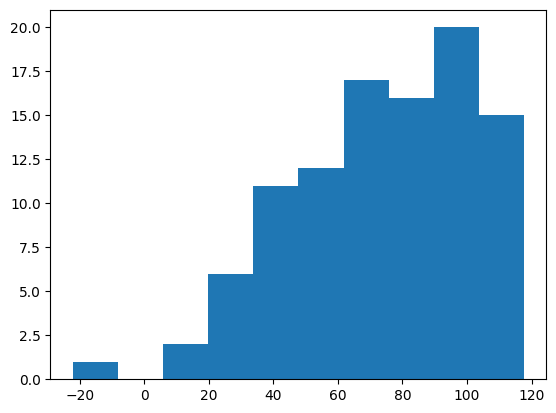

In [35]:
plt.hist(df["calculated_total_u"])

Text(0, 0.5, 'Maria calculated utility')

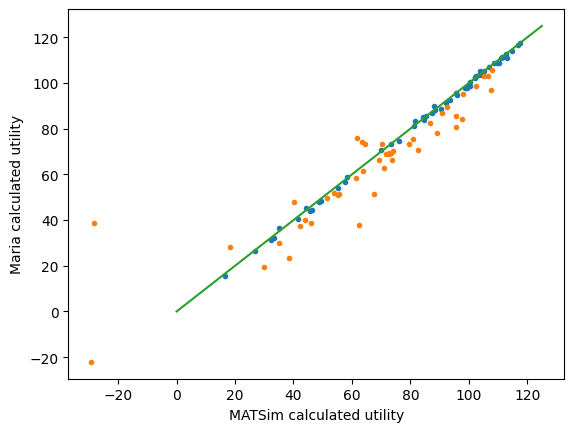

In [36]:
df2 = df[df["diff"]<2]
df3 = df[df["diff"]>=2]
plt.plot(df2["selected plan utility"], df2["calculated_total_u"], ".")
plt.plot(df3["selected plan utility"], df3["calculated_total_u"], ".")
x = [0,50, 100, 125]
y1 = [i*1.1 for i in x ]
y2 = [i*0.9 for i in x ]
y3 = [i+85 for i in x ]
plt.plot(x, x)
# plt.plot(x, y3)
plt.xlabel("MATSim calculated utility")
plt.ylabel("Maria calculated utility")
# plt.plot(x, y1)
# plt.plot(x, y2)
# plt.plot(x, y3)
# plt.ylim(-1000,300)

In [37]:
df["diff_bool"] = df["diff"].apply(lambda x: 1 if x >=2 else 0)

In [38]:
df["unique_modes_trips"] = df["selected plan activity_type_or_mode"].apply(lambda x: list(set(x)))
all_modes = {'bike', 'bus', 'car', 'car_passenger', 'ferry', 'rail', 'subway', 'taxi', 'tram', 'walk'}
df["unique_modes"] = df["unique_modes_trips"].apply(lambda x: [i for i in x if i in all_modes])
df["unique_trips"] = df["unique_modes_trips"].apply(lambda x: [i for i in x if i not in all_modes])

In [39]:
df["len"] = df["selected plan activity_type_or_mode"].apply(lambda x: len(x))
df

,id,age,carAvail,gender,hasBike,hasLicence,hid,household_LAD,household_LSOA,household_zone,...,calculated_penalty_u,total_travel_u,total_activity_u,calculated_total_u,diff,diff_bool,unique_modes_trips,unique_modes,unique_trips,len
0,agent_0,40 to 49,True,female,True,True,hh_0,Wandsworth,E02000923,Wandsworth 001B,...,0,-64.094306,42.012426,-22.081879,7.222383,1,"[gym, bus, home, walk, subway, medical, pt, ed...","[bus, walk, subway]","[gym, home, medical, pt, education, leisure]",17
1,agent_1,85 and over,True,female,True,True,hh_1,Westminster,E02000980,Westminster 021B,...,0,-59.677772,96.214311,36.536538,1.367019,0,"[pub, bus, home, park, walk, subway, medical, ...","[bus, walk, subway, car]","[pub, home, park, medical, work]",23
2,agent_10,0 to 4,True,male,True,True,hh_10,Kensington and Chelsea,E02000592,Kensington and Chelsea 016B,...,0,-56.419359,118.026977,61.607617,2.112471,1,"[bus, home, park, walk, subway, medical]","[bus, walk, subway]","[home, park, medical]",15
3,agent_11,5 to 10,True,female,True,True,hh_11,Wandsworth,E02000923,Wandsworth 001B,...,0,-26.192418,123.825749,97.633331,1.869165,0,"[pub, bus, home, park, walk, bike, medical, car]","[bus, walk, bike, car]","[pub, home, park, medical]",17
4,agent_12,65 to 69,True,female,True,True,hh_12,Westminster,E02000979,Westminster 020E,...,0,-10.584280,119.474881,108.890601,0.792730,0,"[bus, home, walk, car, work]","[bus, walk, car]","[home, work]",9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,agent_95,70 to 74,True,male,True,True,hh_95,Hammersmith and Fulham,E02000385,Hammersmith and Fulham 014A,...,0,-43.475439,119.573117,76.097678,14.235122,1,"[gym, park, home, bus, walk, subway, car, shop]","[bus, walk, subway, car]","[gym, park, home, shop]",17
96,agent_96,26 to 29,True,male,True,True,hh_96,Wandsworth,E02000940,Wandsworth 018A,...,0,-29.796256,119.327231,89.530975,3.111003,1,"[pub, bus, home, walk, bike, subway, medical, ...","[bus, walk, bike, subway]","[pub, home, medical, work]",21
97,agent_97,50 to 59,True,female,True,True,hh_97,Westminster,E02000978,Westminster 019D,...,0,-37.797928,120.365379,82.567452,3.995102,1,"[pub, gym, bus, home, walk, medical, car, shop...","[bus, walk, car, rail]","[pub, gym, home, medical, shop]",27
98,agent_98,40 to 49,True,female,True,True,hh_98,Hammersmith and Fulham,E02000389,Hammersmith and Fulham 018A,...,0,-30.637340,101.480266,70.842926,0.879250,0,"[bus, home, walk, education]","[bus, walk]","[home, education]",13


In [ ]:
# df.to_csv("loninium_testing_nowaitpenalty.csv")

(array([42., 18., 14.,  4.,  2.,  4.,  2.,  4.,  3.,  1.,  2.,  2.,  0.,
         0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([9.36499203e-03, 1.34733315e+00, 2.68530131e+00, 4.02326947e+00,
        5.36123762e+00, 6.69920578e+00, 8.03717394e+00, 9.37514210e+00,
        1.07131103e+01, 1.20510784e+01, 1.33890466e+01, 1.47270147e+01,
        1.60649829e+01, 1.74029510e+01, 1.87409192e+01, 2.00788874e+01,
        2.14168555e+01, 2.27548237e+01, 2.40927918e+01, 2.54307600e+01,
        2.67687282e+01, 2.81066963e+01, 2.94446645e+01, 3.07826326e+01,
        3.21206008e+01, 3.34585689e+01, 3.47965371e+01, 3.61345053e+01,
        3.74724734e+01, 3.88104416e+01, 4.01484097e+01, 4.14863779e+01,
        4.28243461e+01, 4.41623142e+01, 4.55002824e+01, 4.68382505e+01,
        4.81762187e+01, 4.95141868e+01, 5.08521550e+01, 5.21901232e+

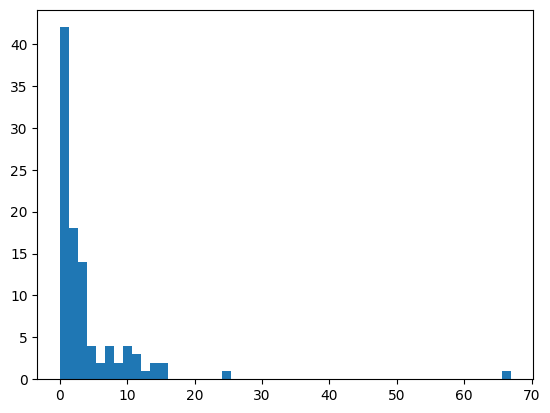

In [41]:
plt.hist(df["diff"], bins=50)
# plt.xlim(-100,100)
# plt.ylim(0,50000)

In [47]:
diffs = list(df["diff"])
calcutils = list(df["calculated_total_u"])
j=0
for i in range(len(diffs)):
    if abs(diffs[i]>5) :
    # if calcutils[i] < -600:
        print("i: "+str(i))
        print("id: "+str(df.iloc[i]["id"]))
        print("diff: "+str(diffs[i]))
        print(df.iloc[i]["subpopulation"])
        j+=1
print(j)

i: 0
id: agent_0
diff: 7.222383414910496
medium income
i: 6
id: agent_14
diff: 66.90777290017726
high income
i: 8
id: agent_16
diff: 9.935204061017334
high income
i: 10
id: agent_18
diff: 8.632540031534347
low income
i: 15
id: agent_22
diff: 7.2819448345923234
high income
i: 16
id: agent_23
diff: 10.404903173064284
low income
i: 18
id: agent_25
diff: 7.806779256895425
medium income
i: 20
id: agent_27
diff: 14.634038991031517
medium income
i: 23
id: agent_3
diff: 10.7323525397806
medium income
i: 27
id: agent_33
diff: 5.188206434269674
low income
i: 37
id: agent_42
diff: 10.357612613643226
high income
i: 41
id: agent_46
diff: 7.143397041260542
high income
i: 49
id: agent_53
diff: 5.028746792521929
high income
i: 55
id: agent_59
diff: 8.218140098069995
high income
i: 57
id: agent_60
diff: 13.370856443894382
medium income
i: 61
id: agent_64
diff: 6.0534934128705515
high income
i: 62
id: agent_65
diff: 11.99638090577767
high income
i: 70
id: agent_72
diff: 15.049928355504022
medium income


In [93]:
df.index[df["diff"]> 15].tolist()

[6, 57, 70, 81, 82]

In [94]:
def calculate_travel_utility(total_activities_modes, total_durations, total_distances, activity_indices, subpopulation, routes, tolls, stuck_id):
    
    trips = moa.group_legs_into_trips(total_activities_modes, activity_indices, stuck_id)
    durations = moa.group_legs_into_trips_d(total_durations, activity_indices, stuck_id, "duration")
    distances = moa.group_legs_into_trips_d(total_distances, activity_indices, stuck_id, "distance")

    # print(trips)
    # print(distances)
    # print(durations)
    routes = list(routes)
    utilities = []
    betaTrans = -1
    match subpopulation:
        case "low income":
            betaMon = 1
        case "medium income":
            betaMon = 1
        case "high income":
            betaMon = 1
    for i in range(len(trips)):
        print("NEW TRIP")
        # print(trips[i])
        STotal = 0
        transferCount = moa.count_transfers(trips[i])
        # print("routes i :"+str(routes[i]))
        for j in range(len(trips[i])):
            print("NEW LEG: "+trips[i][j])
            print("distance is: "+str(distances[i][j]))
            print("duration is: "+str(durations[i][j]))
            match trips[i][j]:
                case "car":
                    CMode = 0
                    betaTrav = -5
                    betaDist = 0
                    gammaDist = -5e-4 
                    
                case "walk":
                    CMode = 0
                    betaTrav = -12
                    betaDist = 0
                    gammaDist = 0

                case "pt":
                    CMode = 0
                    betaTrav = -5
                    betaDist = 0
                    gammaDist = -0.001
                    
                case "bike":
                    CMode = 0
                    betaTrav = -12
                    betaDist = 0
                    gammaDist = 0
                    
                case "bus":
                    CMode = 0
                    betaTrav = -5
                    betaDist = 0
                    gammaDist = -0.001
                    
                case "tram":
                    CMode = 0
                    betaTrav = 0
                    betaDist = 0
                    gammaDist = -4e-4
                    
                case "rail":
                    CMode = 0
                    betaTrav = -5
                    betaDist = 0
                    gammaDist = -0.001
                    
                case "taxi":
                    CMode = 0
                    betaTrav = 0
                    betaDist = 0
                    gammaDist = -0.002
                 
                case "ferry":
                    CMode = 0
                    betaTrav = -5
                    betaDist = 0
                    gammaDist = -0.001

                case "access_walk":
                    CMode = 0
                    betaTrav = -12
                    betaDist = 0
                    gammaDist = 0

                case "egress_walk":
                    CMode = 0
                    betaTrav = -12
                    betaDist = 0
                    gammaDist = 0
                 
                case "subway":
                    CMode = 0
                    betaTrav = -5
                    betaDist = 0
                    gammaDist = -0.001
            # print("mode: "+trips[i][j])
            STime = betaTrav*(durations[i][j]/3600)
            print("STime: "+str(STime))
            print("betaTrav: "+str(betaTrav))
            tollcost = 0 #-1* moa.assign_tolls(tolls, routes[i], trips[i][j])
            # print("tolls: "+str(tolls))
            # print("routes: "+str(routes[i][j]))
            # print("trips: "+str(trips[i][j]))
            # print("toll cost: "+str(tollcost))
            SMon = betaMon * tollcost
            # print("Smon: "+str(SMon))
            SDist = (betaDist + (betaMon*gammaDist))*distances[i][j]
            # print("betaDist: "+str(betaDist))            
            # print("betaMon: "+str(betaMon))            
            # print("gamma: "+str(gammaDist))            
            # print("distance: "+str(distances[i][j]))
            # print("SDist: "+str(SDist))
            # print(CMode)
            STotal_temp = CMode + STime + SMon + SDist 
            STotal += STotal_temp
        STrans = transferCount * betaTrans
        # print("Strans: "+str(STrans))
        STotal += STrans
        # print("STotal: "+str(STotal))
        utilities.append(STotal)
    return(utilities)

In [104]:
calculate_travel_utility(df.iloc[3]["selected plan activity_type_or_mode"], df.iloc[3]["selected plan duration"], df.iloc[3]["selected plan distance_travelled"], df.iloc[3]["activities_indices"], df.iloc[3]["subpopulation"], df.iloc[3]["selected plan routes"], tolls, df.iloc[3]["stuck_index"])

TypeError: calculate_travel_utility() missing 2 required positional arguments: 'tolls' and 'stuck_id'

In [102]:
df.iloc[3]["id"]

'agent_11'

In [97]:
df.index[df['id'] == "agent_11"].tolist()[0]

3

In [100]:
df.iloc[3]["calculated_total_u"]

np.float64(96.29999775947063)